In [1]:
"""
Written by: Tommy Banker (thomas_banker@berkeley.edu)
"""

import os
import json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from utils import *




matplotlib.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            'figure.dpi' : 300,

                            })

font = {'weight' : 'bold',
        'size'   : 34}
plt.rc('font', **font)





In [46]:
df = pd.read_csv('../prop_data/cep.csv')
max(df['y1']*(df['y2']>0))

11.086613

In [47]:
methods = ['cep', ]
best_list = {'cep': 11.086613 }
best = max(df['y1']*(df['y2']>0))  #2.70805020110221 #best_list['cep']
seeds = [0,1,2,3,4,]


In [48]:
sample_configs = [r'./config/cep_constrained/CEP_SAAS_0.json',
                 r'./config/cep_constrained/CEP_GP_full_0.json',
                 r'./config/cep_constrained/CEP_GP_pca_0.json',
                 r'./config/cep_constrained/CEP_Random_0.json']

names = ['SAAS','GP_full','GP_PCA' ,'random']
names2 = ['MolDAIS','SGP',"SGP-PCA", 'Random']

Res_dict_raw = {'SAAS':[], 'GP_full':[],'GP_PCA':[], 'random':[]}        
Res_dict_stat = {'SAAS':[], 'GP_full':[],'GP_PCA':[], 'random':[]}               
Smi_dict_stat = {'SAAS':[], 'GP_full':[],'GP_PCA':[], 'random':[]}         

for i100,sample_config in enumerate(sample_configs):        
    with open(sample_config) as f:
        exp_config = json.load(f)
    ########    
    y_variable = 'cep'#exp_config['common']['y_variable']
    max_min = exp_config['common']['max_min']
    init_budget = exp_config['common']['init_budget']
    total_budget = exp_config['common']['total_budget']
    bo_iters = np.arange(1, total_budget - init_budget + 1)
    ########
    all_results = np.zeros((len(methods), len(seeds), total_budget))
    smi_results = []
    sorted_results = np.zeros((len(methods), len(seeds), total_budget - init_budget + 1))
    conv_results = np.zeros((len(methods), (total_budget - init_budget + 1), 2))
    ########
    for i, method in enumerate(methods):
        for j, seed in enumerate(seeds):
            exp_config['exp_name'] = method #+ '_' + str(seed) 
            exp_config['seed'] = seed
            path = os.path.join('../results/', 'cep_constrained',)
            
            if i100==0 : 
                filename = get_filename(bo_iters[-1], exp_config).replace('89','90')#.replace('SAAS','SAAS_q_1')
            elif i100==1 :
                filename = get_filename(bo_iters[-1], exp_config).replace('90','89').replace('_q_1','').replace('max_y1_Multi-Output-GP','GP_Full_max_y1_Multi-Output-GP_q_1')
            elif i100==2 :
                filename = get_filename(bo_iters[-1], exp_config).replace('90','89').replace('_q_1','').replace('max_y1_Multi-Output-GP','GP_PCA_max_y1_Multi-Output-GP_q_1')
            elif i100==3 :
                filename = get_filename(bo_iters[-1], exp_config).replace('90','89').replace('_q_1','').replace('max_y1_None','random_max_y1_Multi-Output-GP_q_1').replace('randomC','random')
               
            
            print(os.path.join(path, filename + '.pkl'))

            result = torch.load(os.path.join(path, filename + '.pkl'))

                
                
            if i100==0 : all_results[i,j,:] = result['y_train'][:,0]*(result['y_train'][:,1]>-4)
            else:  all_results[i,j,:] = result['y_train'][:,0]*(result['y_train'][:,1]*-1>-4)
                
            smi_results.append( result['smiles_train'])
    ########
    sorted_results[:,:,0] = np.max(all_results[:,:,:init_budget], axis=2)
    for i, method in enumerate(methods):
        for j, seed in enumerate(seeds):
            for sample in np.arange(total_budget - init_budget):
                if all_results[i,j,(init_budget + sample)] > sorted_results[i,j,sample]:
                    sorted_results[i,j,(sample + 1)] = all_results[i,j,(init_budget + sample)]
                else:
                    sorted_results[i,j,(sample + 1)] = sorted_results[i,j,(sample)]
    ########
    for i, method in enumerate(methods):
        for sample in np.arange(total_budget - init_budget + 1):
            conv_results[i,sample,0] = np.mean(sorted_results[i,:,sample])
            conv_results[i,sample,1] = np.std(sorted_results[i,:,sample])
    ########
    sample_numbers = np.arange(total_budget - init_budget + 1)
    #max_min_vars = torch.load('../prop_data/max_min_vars.pkl')
    '''if max_min == 'max':
        conv_results[:,:,0] = (conv_results[:,:,0] )#*-1 + best #- max_min_vars[y_variable]['max']) * -1
    else:   # convention appears strange bc results as stored are already the
            # negative of the true values to perform minimization experiments
        conv_results[:,:,0] = (conv_results[:,:,0] - -1 * max_min_vars[y_variable]['min']) * -1
    '''
    
    Res_dict_raw[names[i100]] = sorted_results
    Res_dict_stat[names[i100]] = conv_results    
    Smi_dict_stat[names[i100]] = smi_results

../results/cep_constrained/cep_max_y1_Multi-Output-SAAS_q_1_seed_0_bo-iter_90_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_max_y1_Multi-Output-SAAS_q_1_seed_1_bo-iter_90_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_max_y1_Multi-Output-SAAS_q_1_seed_2_bo-iter_90_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_max_y1_Multi-Output-SAAS_q_1_seed_3_bo-iter_90_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_max_y1_Multi-Output-SAAS_q_1_seed_4_bo-iter_90_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_GP_Full_max_y1_Multi-Output-GP_q_1_seed_0_bo-iter_89_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_GP_Full_max_y1_Multi-Output-GP_q_1_seed_1_bo-iter_89_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_GP_Full_max_y1_Multi-Output-GP_q_1_seed_2_bo-iter_89_10_to_100_samples_cEI_None_None.pkl
../results/cep_constrained/cep_GP_Full_max_y1_Multi-Output-GP_q_1_seed

/tmp/ipykernel_51165/48149006.py:9: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(sample_numbers, conv_results[0,:,0], style, linewidth=3, label=names2[i], c=colors[i])


"    \n#sorted_results\nfig = plt.figure(figsize=(12,9))\nfor i, method in enumerate(names):\n    \n    style = '-'\n    sorted_results = Res_dict_raw[method]\n    plt.plot(sample_numbers, -1*sorted_results.squeeze(0).T+best, style, linewidth=3, label=method, c=colors[i])\n    #plt.fill_between(sample_numbers, conv_results[i,:,0]-(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), conv_results[i,:,0]+(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), alpha=0.1, color=colors[i])\n    #plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')\nplt.xlabel('Iterations')\nplt.ylabel('Regret' )\n#plt.yscale('log')\nplt.ylim(0,3.5)    \n"

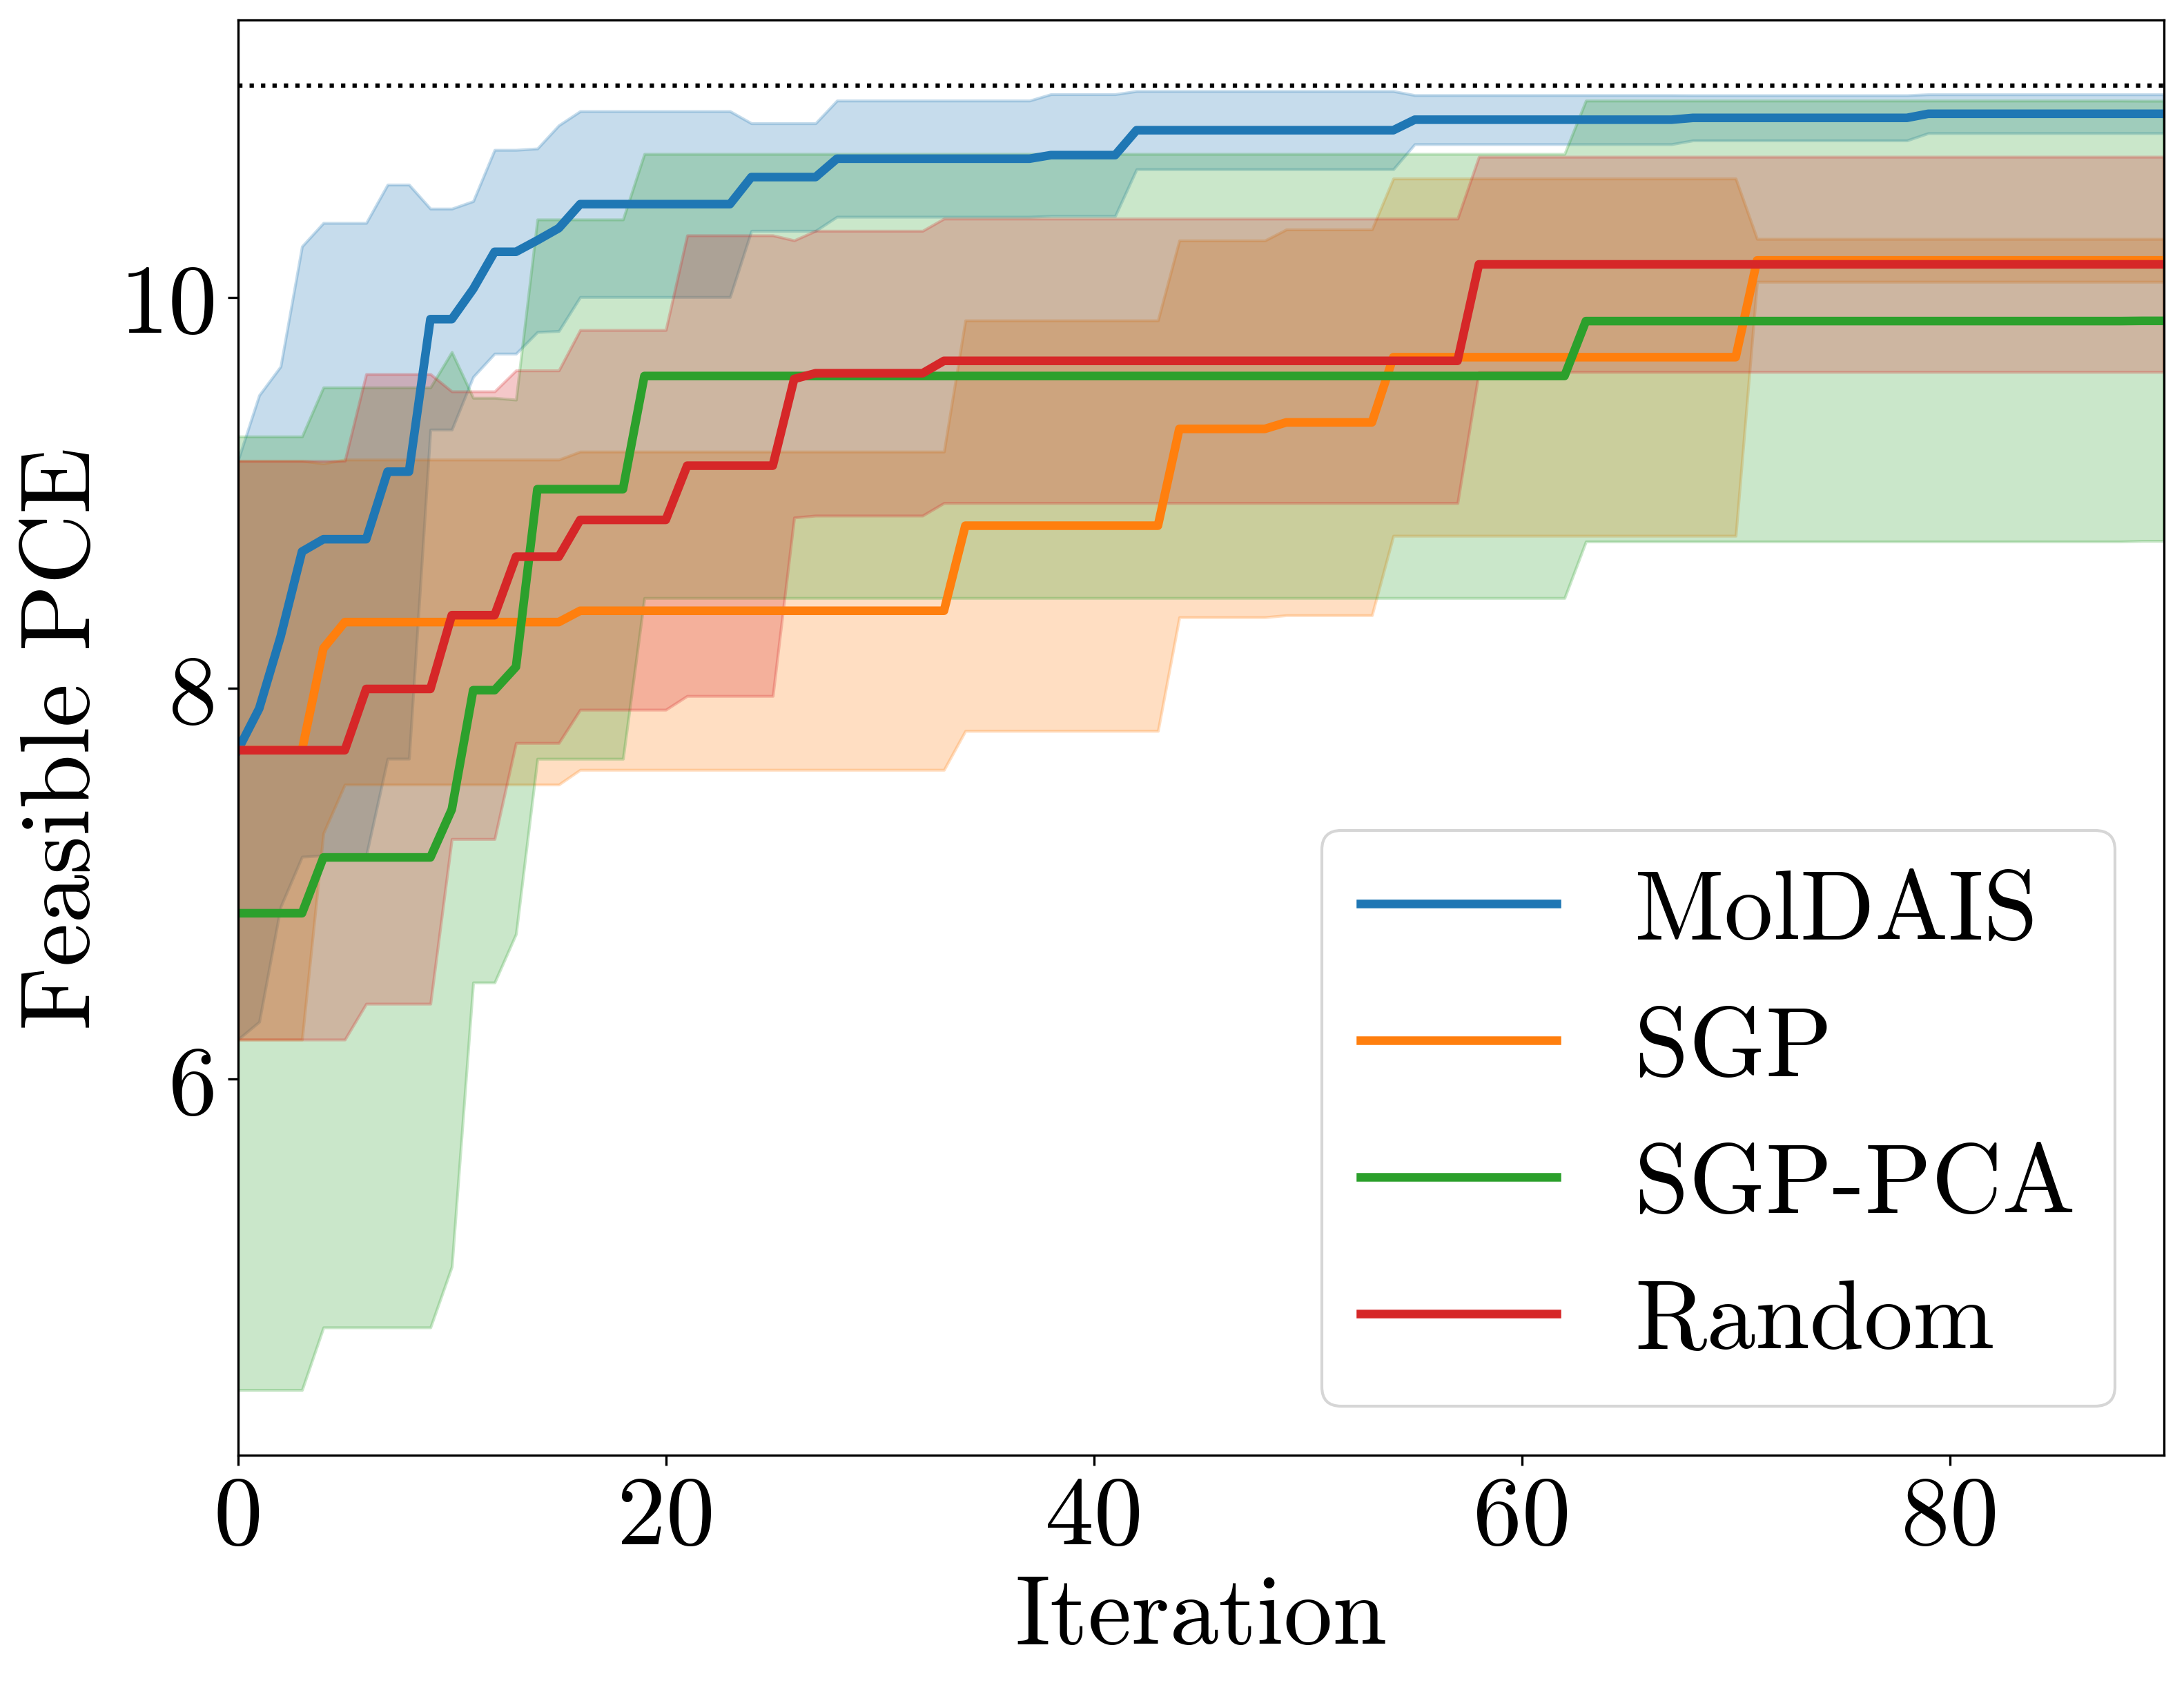

In [50]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#01015c','#0302FC', ] 

end=-1

fig = plt.figure(figsize=(12,9))
for i, method in enumerate(names):
    style = '-'
    conv_results = Res_dict_stat[method]
    plt.plot(sample_numbers, conv_results[0,:,0], style, linewidth=3, label=names2[i], c=colors[i])
    plt.fill_between(sample_numbers, conv_results[0,:,0]-(1.95*conv_results[0,:,1]/(len(seeds)**0.5)), conv_results[0,:,0]+(1.95*conv_results[0,:,1]/(len(seeds)**0.5)), alpha=0.25, color=colors[i])
plt.plot([0,90],[best,best],'k:')
plt.legend(loc=0)
#plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')
plt.xlabel('Iteration')
plt.ylabel('Feasible PCE' )
#plt.yscale('log')
plt.xlim(0,90)    
#plt.ylim(0,3.5)    
plt.savefig('./figs/cep/Convergence_cons.png')
    



'''    
#sorted_results
fig = plt.figure(figsize=(12,9))
for i, method in enumerate(names):
    
    style = '-'
    sorted_results = Res_dict_raw[method]
    plt.plot(sample_numbers, -1*sorted_results.squeeze(0).T+best, style, linewidth=3, label=method, c=colors[i])
    #plt.fill_between(sample_numbers, conv_results[i,:,0]-(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), conv_results[i,:,0]+(1.95*conv_results[i,:,1]/(len(seeds)**0.5)), alpha=0.1, color=colors[i])
    #plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')
plt.xlabel('Iterations')
plt.ylabel('Regret' )
#plt.yscale('log')
plt.ylim(0,3.5)    
'''

In [53]:
Res_dict_raw.keys()

dict_keys(['SAAS', 'GP_full', 'GP_PCA', 'random'])

/tmp/ipykernel_51165/3798201519.py:46: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.axvline(i, color=C[i], linestyle='-', zorder=0)


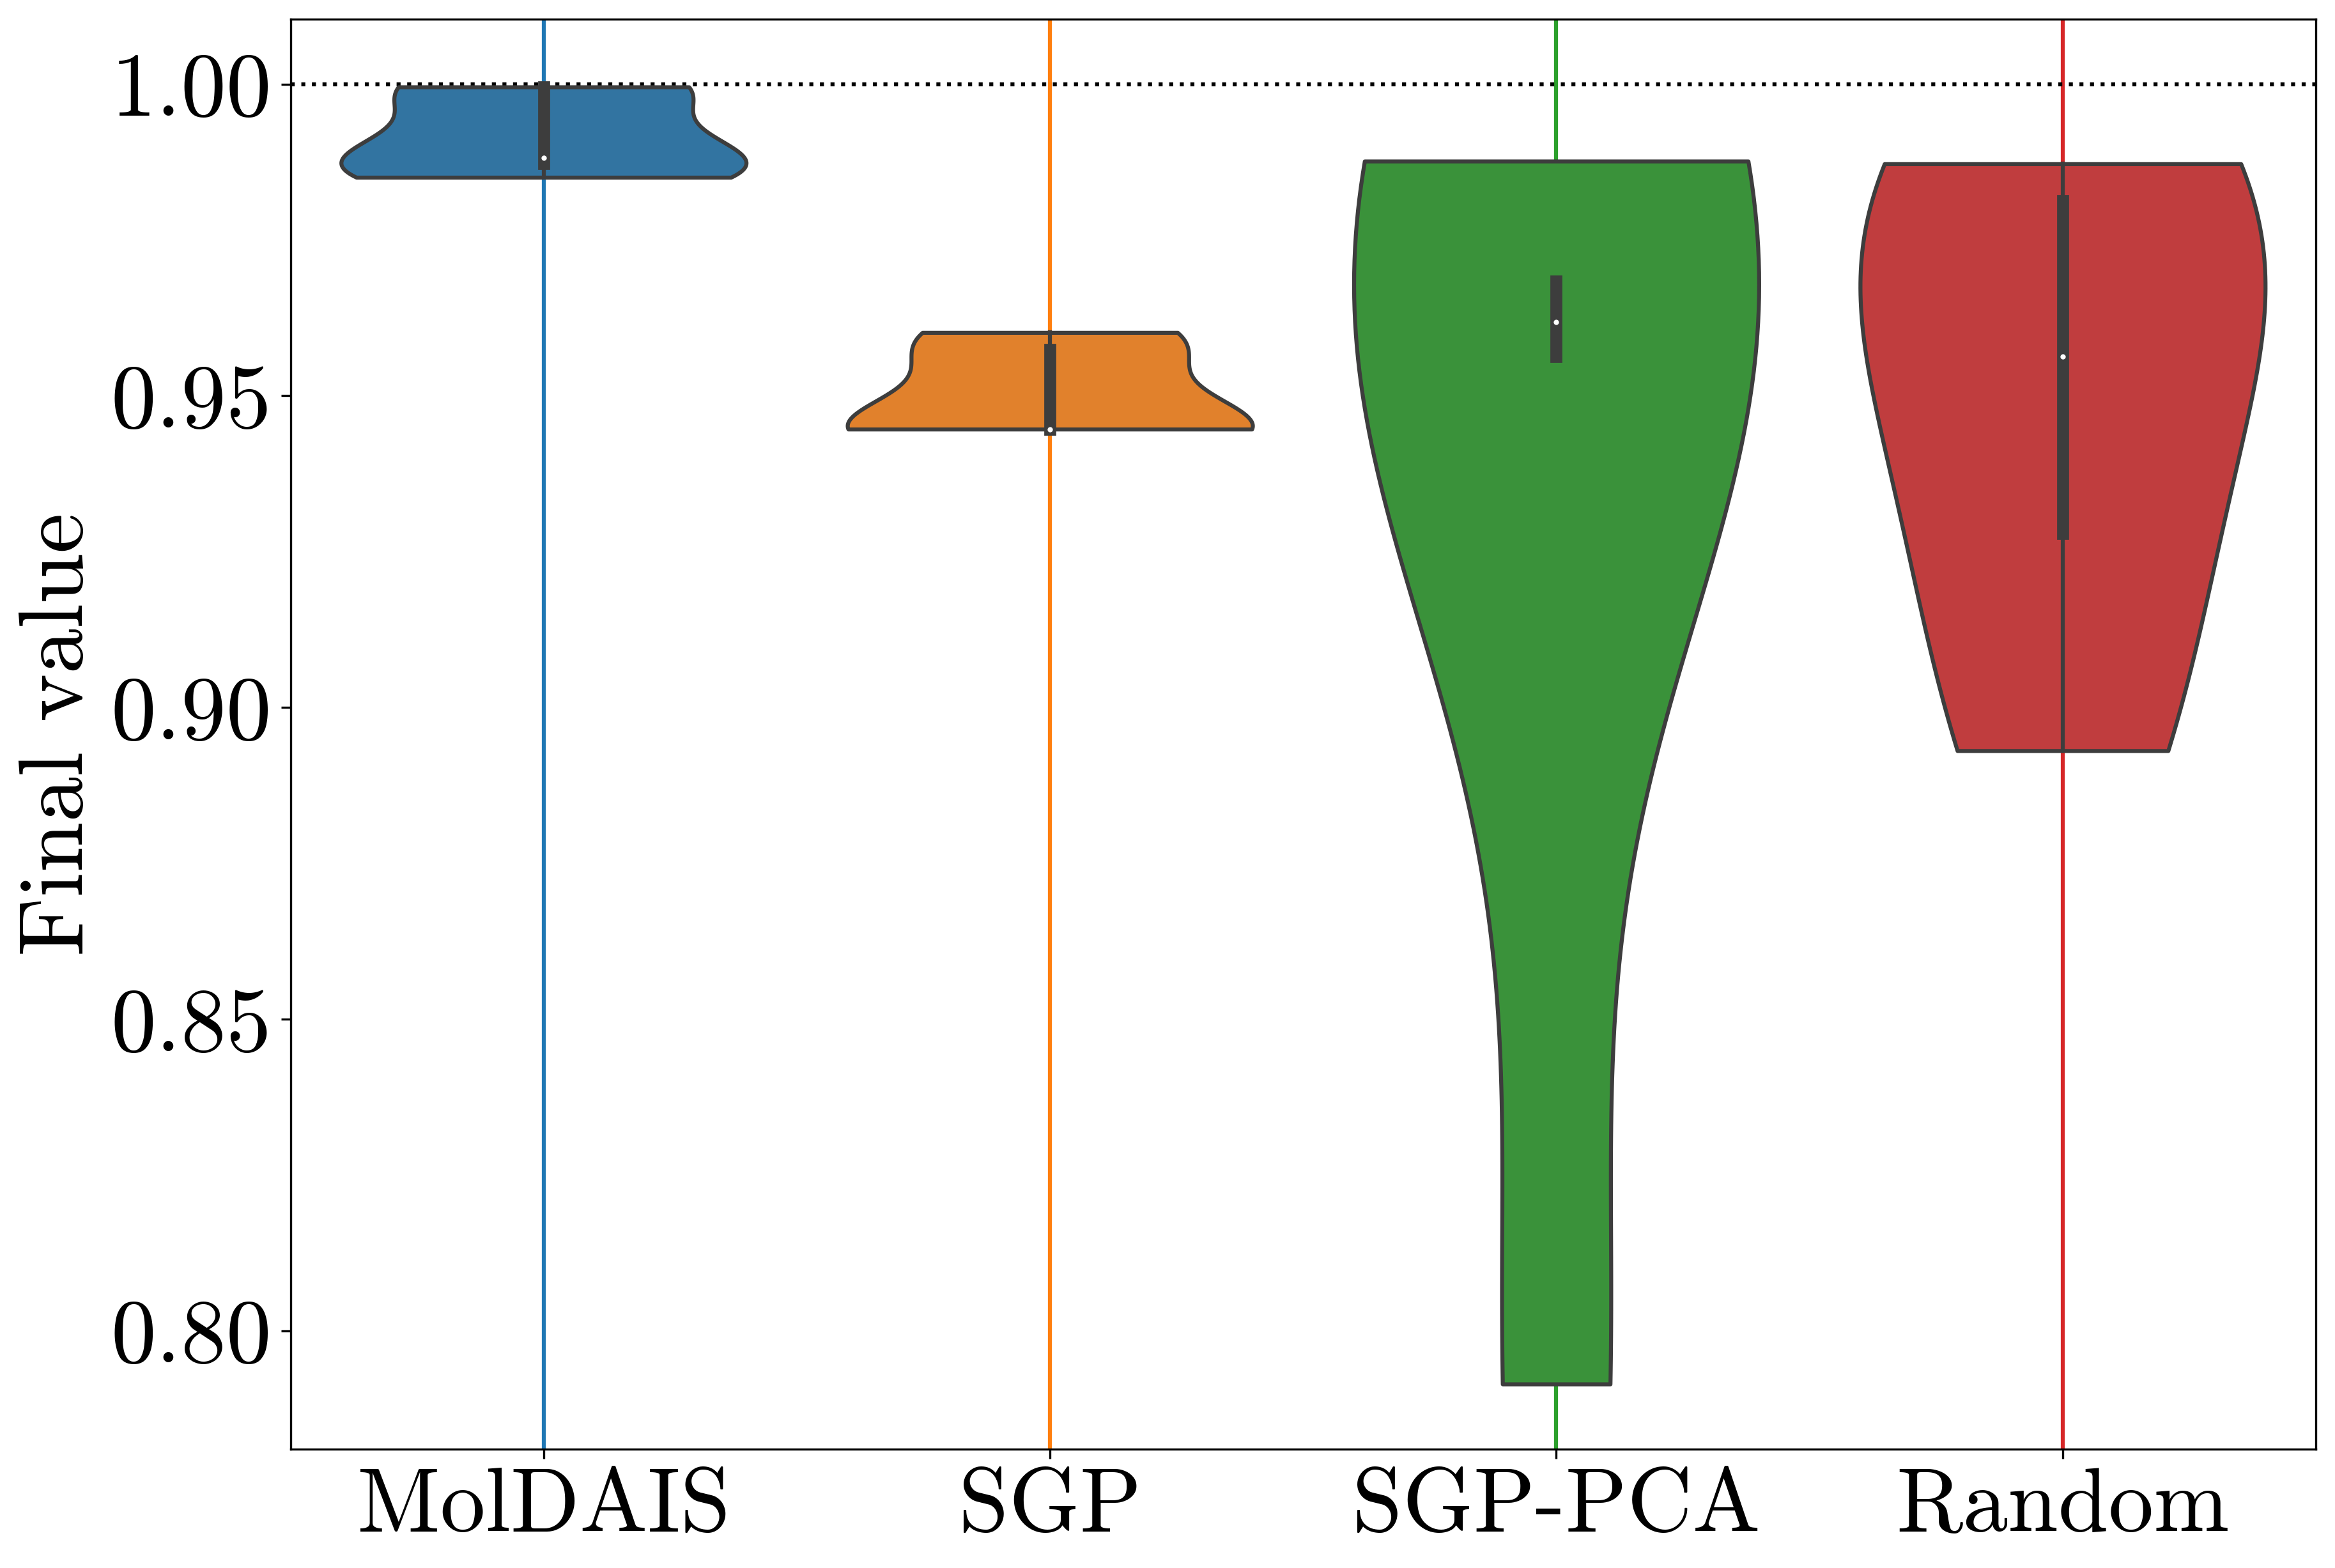

In [58]:
import pandas as pd
import seaborn as sns
sorted_results5 = Res_dict_raw['random']

end = -1
dmin = min(df['y1']*(df['y2']>0))
dmax = max(df['y1']*(df['y2']>0))


sorted_results1 = Res_dict_raw['SAAS']
sorted_results2 = Res_dict_raw['GP_full']
sorted_results3 = Res_dict_raw['GP_PCA']
sorted_results4 = Res_dict_raw['random']







df2 = pd.DataFrame()

d =  pd.DataFrame({'Method':[names2[0]]*len(seeds), 'Final value':(sorted_results1[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':[names2[1]]*len(seeds), 'Final value':(sorted_results2[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':[names2[2]]*len(seeds), 'Final value':(sorted_results3[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':[names2[3]]*len(seeds), 'Final value':(sorted_results4[0,:,end]-dmin)/(dmax-dmin)})
df2 = pd.concat([df2, d])




C = [ sns.color_palette()[0], sns.color_palette()[1],
     sns.color_palette()[2], sns.color_palette()[3], sns.color_palette()[4],
     sns.color_palette()[5], sns.color_palette()[6], sns.color_palette()[7],]
     #sns.color_palette()[8], sns.color_palette()[9], sns.color_palette()[10]]


plt.figure(figsize=(13,9))
for i,ls in enumerate(range(4)):
  plt.axvline(i, color=C[i], linestyle='-', zorder=0)
plt.axhline(1,color='k', linestyle=':',zorder=0)
sns.violinplot(data=df2, x='Method', y='Final value', cut=0, inner="box", scale='width', palette=C, linestyle='dashdot')
#plt.title('Lipophilicity')
plt.xlabel(None)
#plt.ylim(.93,1.001)
#density_norm{“area”, “count”, “width”}
plt.tight_layout()
plt.savefig('./figs/cep/cep_cons_finalVals.png')
